In [1]:
!pip install open_clip_torch

import torch
import open_clip
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")
print(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
cuda


In [2]:
clip_model,_,preprocess=open_clip.create_model_and_transforms("ViT-B-32",pretrained="openai")
tokenizer=open_clip.get_tokenizer("ViT-B-32")
clip_model=clip_model.to(device)
clip_model.eval()

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [3]:
stl10_test=datasets.STL10(root="./data",split="test",download=True,transform=preprocess)
stl10_loader=DataLoader(stl10_test,batch_size=128,shuffle=False)
stl10_classes=list(stl10_test.classes)
print(stl10_classes)

100%|██████████| 2.64G/2.64G [04:48<00:00, 9.17MB/s]


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
plain_prompts=stl10_classes

photo_prompts=[]
for c in stl10_classes:
    photo_prompts.append("a photo of a "+c)

descriptive_prompts=[
    "a large aircraft flying in the sky",
    "a small bird with feathers and wings",
    "a passenger car on the road",
    "a domestic cat with fur and whiskers",
    "a deer with antlers in the wild",
    "a pet dog with four legs",
    "a horse standing in a field",
    "a primate monkey with a tail",
    "a large ship sailing on water",
    "a heavy truck on the highway"
]

In [5]:
def zero_shot_accuracy(loader,prompts):
    text_tokens=tokenizer(prompts).to(device)
    with torch.no_grad():
        text_features=clip_model.encode_text(text_tokens)
        text_features=text_features/text_features.norm(dim=-1,keepdim=True)

    correct=0
    total=0
    for images,labels in loader:
        images=images.to(device)
        with torch.no_grad():
            image_features=clip_model.encode_image(images)
            image_features=image_features/image_features.norm(dim=-1,keepdim=True)
        similarities=image_features@text_features.T
        predictions=similarities.argmax(dim=-1)
        correct=correct+(predictions.cpu()==labels).sum().item()
        total=total+len(labels)
    return correct/total

In [6]:
plain_accuracy=zero_shot_accuracy(stl10_loader,plain_prompts)
print("plain accuracy:",plain_accuracy,4)

photo_accuracy=zero_shot_accuracy(stl10_loader,photo_prompts)
print("photo accuracy:",photo_accuracy,4)

descriptive_accuracy=zero_shot_accuracy(stl10_loader,descriptive_prompts)
print("descriptive accuracy:",descriptive_accuracy,4)

plain accuracy: 0.964125 4
photo accuracy: 0.959375 4
descriptive accuracy: 0.93475 4


In [7]:
subset_images=[]
subset_labels=[]
for i in range(75):
    image,label=stl10_test[i]
    subset_images.append(image)
    subset_labels.append(label)

subset_images=torch.stack(subset_images).to(device)
subset_labels=torch.tensor(subset_labels).to(device)

with torch.no_grad():
    image_features=clip_model.encode_image(subset_images)
    normalized_image_features=image_features/image_features.norm(dim=-1,keepdim=True)
    text_tokens=tokenizer(plain_prompts).to(device)
    text_features=clip_model.encode_text(text_tokens)
    normalized_text_features=text_features/text_features.norm(dim=-1,keepdim=True)

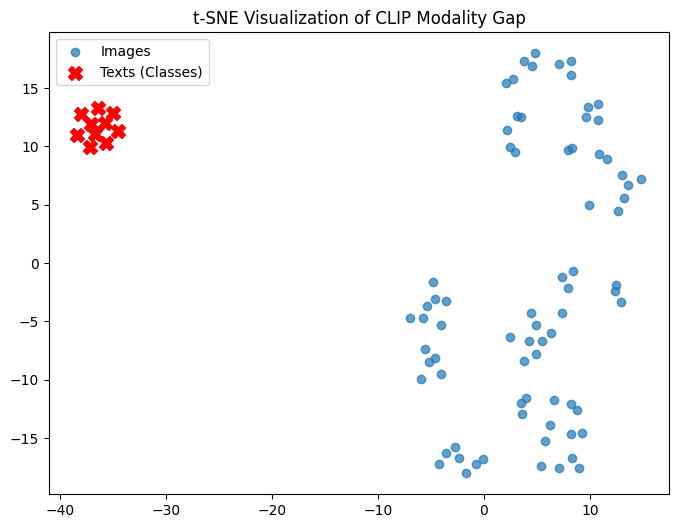

In [8]:
from sklearn.manifold import TSNE
import numpy as np

numpy_image_features=normalized_image_features.cpu().numpy()
numpy_text_features=normalized_text_features.cpu().numpy()
combined_features=np.vstack((numpy_image_features,numpy_text_features))

tsne_model=TSNE(n_components=2,perplexity=10,random_state=42)
two_dimensional_features=tsne_model.fit_transform(combined_features)

two_dimensional_images=two_dimensional_features[:75]
two_dimensional_texts=two_dimensional_features[75:]

plt.figure(figsize=(8,6))
plt.scatter(two_dimensional_images[:,0],two_dimensional_images[:,1],label='Images',alpha=0.7)
plt.scatter(two_dimensional_texts[:,0],two_dimensional_texts[:,1],label='Texts (Classes)',c='red',marker='X',s=100)
plt.title("t-SNE Visualization of CLIP Modality Gap")
plt.legend()
plt.savefig("modality_gap_before.png",bbox_inches="tight")
plt.show()

In [9]:
subset_text_features=normalized_text_features[subset_labels]
source_image_features=normalized_image_features.cpu().numpy()
target_text_features=subset_text_features.cpu().numpy()

In [10]:
source_image_tensors=normalized_image_features
target_text_tensors=subset_text_features

covariance_matrix=torch.matmul(source_image_tensors.T,target_text_tensors)
u_matrix,singular_values,vh_matrix=torch.linalg.svd(covariance_matrix)
rotation_tensor=torch.matmul(u_matrix,vh_matrix)

rotated_image_tensors=torch.matmul(source_image_tensors,rotation_tensor)
rotated_image_features=rotated_image_tensors.cpu().numpy()
rotation_matrix=rotation_tensor.cpu().numpy()

In [11]:
def rotated_zero_shot_accuracy(loader,prompts,rotation_matrix):
    text_tokens=tokenizer(prompts).to(device)
    with torch.no_grad():
        text_features=clip_model.encode_text(text_tokens)
        normalized_text_features=text_features/text_features.norm(dim=-1,keepdim=True)

    rotation_tensor=torch.tensor(rotation_matrix,dtype=torch.float32).to(device)
    correct=0
    total=0
    for images,labels in loader:
        images=images.to(device)
        with torch.no_grad():
            image_features=clip_model.encode_image(images)
            normalized_image_features=image_features/image_features.norm(dim=-1,keepdim=True)
            rotated_image_features=torch.matmul(normalized_image_features,rotation_tensor)

        similarities=rotated_image_features@normalized_text_features.T
        predictions=similarities.argmax(dim=-1)

        correct=correct+(predictions.cpu()==labels).sum().item()
        total=total+len(labels)

    return correct/total

rotated_accuracy=rotated_zero_shot_accuracy(stl10_loader,plain_prompts,rotation_matrix)
print("rotated accuracy:",rotated_accuracy)

rotated accuracy: 0.96025


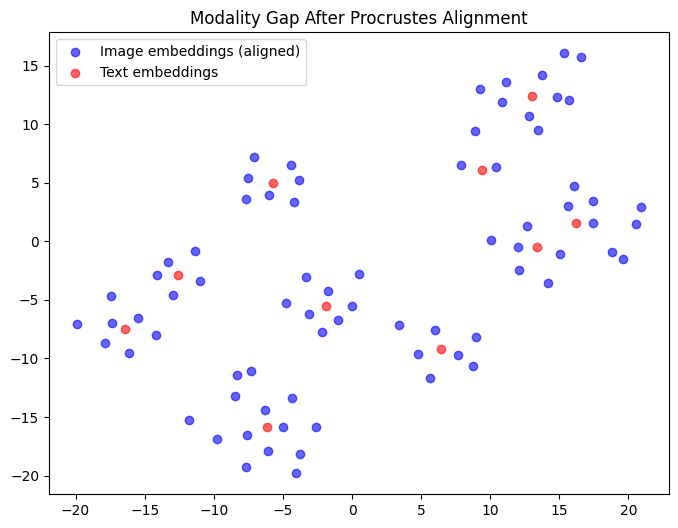

In [12]:
rotated_combined=np.vstack((rotated_image_features,numpy_text_features))

tsne_aligned=TSNE(n_components=2,perplexity=10,random_state=42)
two_dimensional_aligned=tsne_aligned.fit_transform(rotated_combined)

two_dimensional_rotated_images=two_dimensional_aligned[:75]
two_dimensional_rotated_texts=two_dimensional_aligned[75:]

plt.figure(figsize=(8,6))
plt.scatter(two_dimensional_rotated_images[:,0],two_dimensional_rotated_images[:,1],c="blue",label="Image embeddings (aligned)",alpha=0.6)
plt.scatter(two_dimensional_rotated_texts[:,0],two_dimensional_rotated_texts[:,1],c="red",label="Text embeddings",alpha=0.6)
plt.title("Modality Gap After Procrustes Alignment")
plt.legend()
plt.savefig("modality_gap_aligned.png",bbox_inches="tight")
plt.show()